# Zonal_mpsi using UXarray

Work on [NCL's zonal_mpsi](https://www.ncl.ucar.edu/Document/Functions/Built-in/zonal_mpsi.shtml) with a UXarray dataset.

Zonal mean meridional stream function

*v*: A multi-dimensional array of meridional wind values

*lat*: A one-dimensional array of latitudes.

*p*: A one-dimensional array of pressure level values ordered top-to-bottom.

*ps*: A multi-dimensional numeric array of surface pressures.

$MPSI(lev,lat) = \frac{2 {\pi} a cos(lat)}{g} \int_{p}^{PS} \bar{v} \,dp$

In [1]:
import uxarray as ux
import xarray as xr
import numpy as np
import geocat.datafiles as gdf
import geocat.comp as gc
import matplotlib.pyplot as plt

## Read in Data

Need a datset with: wind speed values (lat, long, time, maybe lev), vertical pressure levels, and spatial surface pressure

In [2]:
data_path = 'netcdf_files/e2p3b09.F2000climo.ne30pg3.ctl002.cam.h0.0005-01.zonal_mpsi_subset.nc'
grid_path = 'netcdf_files/ne30pg3_scrip_170604.nc'
uxds = ux.open_dataset(gdf.get(grid_path), gdf.get(data_path)).drop('lat') #dropping lat to avoid using it instead of the UXarray grid

uxds

/var/folders/dd/_xm_pbpd3flgbvbnt7qhd70snnbpj_/T/ipykernel_56308/1643203269.py:3: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  uxds = ux.open_dataset(gdf.get(grid_path), gdf.get(data_path)).drop('lat') #dropping lat to avoid using it instead of the UXarray grid


<xarray.UxDataset> Size: 6MB
Dimensions:  (time: 1, n_face: 48600, lev: 32, ilev: 33)
Coordinates:
  * lev      (lev) float64 256B 3.643 7.595 14.36 24.61 ... 957.5 976.3 992.6
  * ilev     (ilev) float64 264B 2.255 5.032 10.16 18.56 ... 967.5 985.1 1e+03
  * time     (time) object 8B 0005-02-01 00:00:00
Dimensions without coordinates: n_face
Data variables:
    PS       (time, n_face) float32 194kB ...
    V        (time, lev, n_face) float32 6MB ...
    hyam     (lev) float64 256B ...
    hybm     (lev) float64 256B ...
    hyai     (ilev) float64 264B ...
    hybi     (ilev) float64 264B ...

The data hasn't been interpolated to pressure levels (still on hybrid sigma levels)

## Converting from sigma hybrid coordinates to Pressure levels

$p(k) = hya(k) * p_0 + hyb(k) * p_{surface}$

Source: [NCL `sigma2hybrid` documentation](https://www.ncl.ucar.edu/Document/Functions/Built-in/sigma2hybrid.shtml)


['geocat_comp.delta_pressure()`](https://geocat-comp.readthedocs.io/en/latest/user_api/generated/geocat.comp.meteorology.delta_pressure.html)

['geocat_comp.dpres_plev()`](https://geocat-comp.readthedocs.io/en/latest/user_api/generated/geocat.comp.meteorology.dpres_plev.html)

['geocat_comp.interp_hybrid_to_pressure()'](https://geocat-comp.readthedocs.io/en/latest/user_api/generated/geocat.comp.interpolation.interp_hybrid_to_pressure.html)

### <font color='red'>Ouput type is Xr.DataArray instead of UX.DataArray</font> 
Work on making geocat-comp spit out the same time it ingests without needed to add UXarray as a dependency.


In [3]:
da_ipress = gc.interpolation.interp_hybrid_to_pressure(
    uxds.V, 
    uxds.PS, 
    uxds.hyam, 
    uxds.hybm)
da_ipress

<xarray.DataArray 'V' (time: 1, plev: 21, n_face: 48600)> Size: 4MB
dask.array<_vertical_remap, shape=(1, 21, 48600), dtype=float32, chunksize=(1, 21, 48600), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 8B 0005-02-01 00:00:00
  * plev     (plev) float32 84B 1e+05 9.25e+04 8.5e+04 ... 300.0 200.0 100.0
Dimensions without coordinates: n_face
Attributes:
    mdims:         1
    units:         m/s
    long_name:     Meridional wind
    cell_methods:  time: mean

In [4]:
ux_ipress = ux.UxDataArray(da_ipress, uxgrid=uxds.uxgrid)
ux_ipress 

<xarray.UxDataArray 'V' (time: 1, plev: 21, n_face: 48600)> Size: 4MB
dask.array<_vertical_remap, shape=(1, 21, 48600), dtype=float32, chunksize=(1, 21, 48600), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 8B 0005-02-01 00:00:00
  * plev     (plev) float32 84B 1e+05 9.25e+04 8.5e+04 ... 300.0 200.0 100.0
Dimensions without coordinates: n_face
Attributes:
    mdims:         1
    units:         m/s
    long_name:     Meridional wind
    cell_methods:  time: mean

## Performing Zonal Means

In [5]:
# zonal mean wind
ux_v_zonal = ux_ipress.zonal_mean()
ux_v_zonal

<xarray.UxDataArray 'V_zonal_mean' (time: 1, plev: 21, latitudes: 19)> Size: 2kB
dask.array<setitem, shape=(1, 21, 19), dtype=float32, chunksize=(1, 21, 19), chunktype=numpy.ndarray>
Coordinates:
  * latitudes  (latitudes) int64 152B -90 -80 -70 -60 -50 -40 ... 50 60 70 80 90
Dimensions without coordinates: time, plev
Attributes:
    zonal_mean:  True

In [6]:
ux_v_zonal.isel(time=0, plev=10).plot.line()

:Curve   [latitudes]   (V_zonal_mean)

### <font color='red'>Pressure Levels Pointing to Indices Only</font> 
`plev` should be an array of: [100000.,  92500.,  85000.,  70000.,  50000.,  40000.,  30000.,  25000.,
        20000.,  15000.,  10000.,   7000.,   5000.,   3000.,   2000.,   1000.,
          700.,    500.,    300.,    200.,    100.] not [0:20]

Adding back in a `plev` coordinate. Does UX.zonal_mean() drop all other coordinates?

In [7]:
ux_v_zonal.plev

<xarray.UxDataArray 'plev' (plev: 21)> Size: 168B
array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20])
Dimensions without coordinates: plev

In [8]:
ux_v_zonal['plev'] = ux_ipress.plev
ux_v_zonal

<xarray.UxDataArray 'V_zonal_mean' (time: 1, plev: 21, latitudes: 19)> Size: 2kB
dask.array<setitem, shape=(1, 21, 19), dtype=float32, chunksize=(1, 21, 19), chunktype=numpy.ndarray>
Coordinates:
  * latitudes  (latitudes) int64 152B -90 -80 -70 -60 -50 -40 ... 50 60 70 80 90
  * plev       (plev) float32 84B 1e+05 9.25e+04 8.5e+04 ... 300.0 200.0 100.0
Dimensions without coordinates: time
Attributes:
    zonal_mean:  True

### <font color='red'>Improve `gc.meteorology.delta_pressure(plev, PS)`</font> 

All of our pressure levels in space are identical EXCEPT for the very first index which depends on surface pressure. How can we leverage that logic to speed up the computation. Over 3 minutes is too long

Takes less time if instead of finding `dp` for all 48600 faces, we average surface pressure first and look at 19 latitudes?

### <font color='red'>Ouput type is Numpy Array instead of UX.DataArray</font> 

In [9]:
# zonal mean Surface pressure
ux_PS_zonal = uxds.PS.zonal_mean()
ux_PS_zonal

<xarray.UxDataArray 'PS_zonal_mean' (time: 1, latitudes: 19)> Size: 76B
array([[ 67811.09 ,  78607.555,  89532.234,  98368.2  , 100244.914,
        101444.77 , 100448.18 ,  99279.34 ,  99575.53 ,  99954.55 ,
         99828.26 ,  99917.07 ,  97050.13 ,  96911.39 ,  97549.914,
         98085.555,  97363.945,  97557.445, 100496.2  ]], dtype=float32)
Coordinates:
  * latitudes  (latitudes) int64 152B -90 -80 -70 -60 -50 -40 ... 50 60 70 80 90
Dimensions without coordinates: time
Attributes:
    zonal_mean:  True

## Find integration deltas

In [10]:
# Super quick when not applied to every face, still performing unnecessary calculations but that is not a problem here
# Again outputs a numpy array
np_dp_zonal = gc.meteorology.delta_pressure(ux_v_zonal.plev, ux_PS_zonal)
np_dp_zonal

array([[[          nan,           nan,           nan,  7811.09375  ,
         15000.       , 10000.       ,  7500.       ,  5000.       ,
          5000.       ,  5000.       ,  4000.       ,  2500.       ,
          2000.       ,  1500.       ,  1000.       ,   650.       ,
           250.       ,   200.       ,   150.       ,   100.       ,
            50.       ],
        [          nan,           nan,  1107.5546875, 17500.       ,
         15000.       , 10000.       ,  7500.       ,  5000.       ,
          5000.       ,  5000.       ,  4000.       ,  2500.       ,
          2000.       ,  1500.       ,  1000.       ,   650.       ,
           250.       ,   200.       ,   150.       ,   100.       ,
            50.       ],
        [          nan,   782.234375 , 11250.       , 17500.       ,
         15000.       , 10000.       ,  7500.       ,  5000.       ,
          5000.       ,  5000.       ,  4000.       ,  2500.       ,
          2000.       ,  1500.       ,  1000.       ,

In [11]:
da_dp_zonal = xr.DataArray(
    np_dp_zonal,
    dims=["time", "latitudes", "plev"],
    coords={
        "plev": ux_v_zonal.plev,
        "latitudes": ux_v_zonal.latitudes
        },
    name="delta_pressure"
)
ux_dp_zonal = ux.UxDataArray(da_dp_zonal, uxgrid=uxds.uxgrid)
ux_dp_zonal

<xarray.UxDataArray 'delta_pressure' (time: 1, latitudes: 19, plev: 21)> Size: 3kB
array([[[          nan,           nan,           nan,  7811.09375  ,
         15000.       , 10000.       ,  7500.       ,  5000.       ,
          5000.       ,  5000.       ,  4000.       ,  2500.       ,
          2000.       ,  1500.       ,  1000.       ,   650.       ,
           250.       ,   200.       ,   150.       ,   100.       ,
            50.       ],
        [          nan,           nan,  1107.5546875, 17500.       ,
         15000.       , 10000.       ,  7500.       ,  5000.       ,
          5000.       ,  5000.       ,  4000.       ,  2500.       ,
          2000.       ,  1500.       ,  1000.       ,   650.       ,
           250.       ,   200.       ,   150.       ,   100.       ,
            50.       ],
        [          nan,   782.234375 , 11250.       , 17500.       ,
         15000.       , 10000.       ,  7500.       ,  5000.       ,
          5000.       ,  5000.       ,  4000.       ,  2500.       ,
          2000.       ,  1500.       ,  1000.       ,   650.       ,
           250.       ,   200.       ,   150.       ,   100.       ,
            50.       ],
        [ 2118.203125 ,  7500.       , 11250.       , 17500.       ,
         15000.       , 10000.       ,  7500.       ,  5000.       ,
...
           250.       ,   200.       ,   150.       ,   100.       ,
            50.       ],
        [ 1113.9453125,  7500.       , 11250.       , 17500.       ,
         15000.       , 10000.       ,  7500.       ,  5000.       ,
          5000.       ,  5000.       ,  4000.       ,  2500.       ,
          2000.       ,  1500.       ,  1000.       ,   650.       ,
           250.       ,   200.       ,   150.       ,   100.       ,
            50.       ],
        [ 1307.4453125,  7500.       , 11250.       , 17500.       ,
         15000.       , 10000.       ,  7500.       ,  5000.       ,
          5000.       ,  5000.       ,  4000.       ,  2500.       ,
          2000.       ,  1500.       ,  1000.       ,   650.       ,
           250.       ,   200.       ,   150.       ,   100.       ,
            50.       ],
        [ 4246.203125 ,  7500.       , 11250.       , 17500.       ,
         15000.       , 10000.       ,  7500.       ,  5000.       ,
          5000.       ,  5000.       ,  4000.       ,  2500.       ,
          2000.       ,  1500.       ,  1000.       ,   650.       ,
           250.       ,   200.       ,   150.       ,   100.       ,
            50.       ]]])
Coordinates:
  * plev       (plev) float32 84B 1e+05 9.25e+04 8.5e+04 ... 300.0 200.0 100.0
  * latitudes  (latitudes) int64 152B -90 -80 -70 -60 -50 -40 ... 50 60 70 80 90
Dimensions without coordinates: time

## Perform integration

### <font color='red'>Need to Double Check Orientation</font> 

I need to make sure that dp_ux is oriented as expected (top to bottom or bottom to top)

In [12]:
# Constants
a = 6.371e6  # Earth radius (m)
g = 9.80665  # gravity (m/s^2)

lat = ux_v_zonal.latitudes
da_scaling_factor = 2 * np.pi * a * np.cos(lat) / g
da_scaling_factor

<xarray.DataArray 'latitudes' (latitudes: 19)> Size: 152B
array([-1829010.37924921,  -450594.29399683,  2585172.06576331,
       -3887694.26229467,  3938935.07272736, -2722402.28651777,
         629645.42589202,  1665767.18595934, -3425041.06550859,
        4081941.70201253, -3425041.06550859,  1665767.18595934,
         629645.42589202, -2722402.28651777,  3938935.07272736,
       -3887694.26229467,  2585172.06576331,  -450594.29399683,
       -1829010.37924921])
Coordinates:
  * latitudes  (latitudes) int64 152B -90 -80 -70 -60 -50 -40 ... 50 60 70 80 90

In [13]:
ux_mpsi = (ux_v_zonal * ux_dp_zonal).cumsum()
ux_mpsi = ux_mpsi * da_scaling_factor
ux_mpsi

<xarray.UxDataArray (time: 1, plev: 21, latitudes: 19)> Size: 3kB
dask.array<mul, shape=(1, 21, 19), dtype=float64, chunksize=(1, 21, 19), chunktype=numpy.ndarray>
Coordinates:
  * latitudes  (latitudes) int64 152B -90 -80 -70 -60 -50 -40 ... 50 60 70 80 90
  * plev       (plev) float32 84B 1e+05 9.25e+04 8.5e+04 ... 300.0 200.0 100.0
Dimensions without coordinates: time

# Plotting

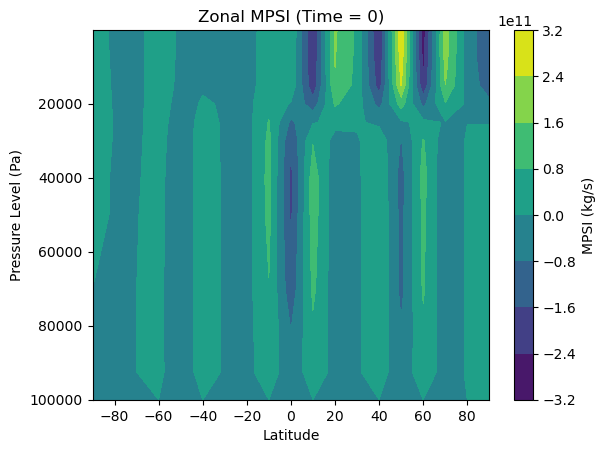

In [14]:
mpsi0 = ux_mpsi.isel(time=0)
plt.contourf(
    mpsi0['latitudes'],
    mpsi0['plev'],
    mpsi0
)
plt.xlabel("Latitude")
plt.ylabel("Pressure Level (Pa)")
plt.gca().invert_yaxis()
plt.colorbar(label="MPSI (kg/s)")
plt.title("Zonal MPSI (Time = 0)")
plt.show()